In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.dpi'] = 120

In [2]:
from pathlib import Path

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "AI_client_customer_segmentation_data.csv"

print("Notebook directory:", BASE_DIR)
print("CSV exists?", DATA_PATH.exists())

Notebook directory: /Users/skyleryu/Desktop/Python API
CSV exists? True


In [6]:
# Read & Inspect

df = pd.read_csv(DATA_PATH)

display(df.head())

print("Shape:", df.shape)

df.info()

df.describe().round(2)

,user_id,role,logins_last_month,avg_session_minutes,feature_clicks,reports_generated
0,U0074,Retail Trader,14,50.9,73,26
1,U0019,Quantitative Researcher,17,62.5,48,39
2,U0118,Financial Advisor,6,31.5,23,3
3,U0079,Portfolio Manager,11,46.5,60,20
4,U0077,Portfolio Manager,9,40.9,60,17


Shape: (149, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              149 non-null    object 
 1   role                 149 non-null    object 
 2   logins_last_month    149 non-null    int64  
 3   avg_session_minutes  149 non-null    float64
 4   feature_clicks       149 non-null    int64  
 5   reports_generated    149 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 7.1+ KB


,logins_last_month,avg_session_minutes,feature_clicks,reports_generated
count,149.00,149.00,149.00,149.00
mean,11.30,39.17,49.95,20.73
std,5.85,11.98,27.75,12.94
min,0.00,11.00,5.00,1.00
25%,6.00,31.50,22.00,8.00
50%,12.00,40.80,57.00,23.00
75%,16.00,47.70,74.00,32.00
max,22.00,72.00,102.00,46.00


In [7]:
print("Missing values:")
display(df.isna().sum())

print("Duplicate user IDs:")
print(df["user_id"].duplicated().sum())

print("Duplicate rows:")
print(df.duplicated().sum())

Missing values:


user_id                0
role                   0
logins_last_month      0
avg_session_minutes    0
feature_clicks         0
reports_generated      0
dtype: int64

Duplicate user IDs:
0
Duplicate rows:
0


In [9]:
# Validation Function

def load_and_validate(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required_columns = [
        "user_id",
        "role",
        "logins_last_month",
        "avg_session_minutes",
        "feature_clicks",
        "reports_generated"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    if df["user_id"].isna().any():
        raise ValueError("Missing user IDs were found.")

    if df["user_id"].duplicated().any():
        raise ValueError("Duplicate user IDs were found.")

    numeric_cols = [
        "logins_last_month",
        "avg_session_minutes",
        "feature_clicks",
        "reports_generated"
    ]

    for column in numeric_cols:
        if df[column].isna().any():
            raise ValueError(
                f"Missing values found in {column}."
            )

        if (df[column] < 0).any():
            raise ValueError(
                f"Negative values found in {column}."
            )

    print("Data validation completed successfully.")

    return df

In [11]:
df = load_and_validate(DATA_PATH)

Data validation completed successfully.


In [13]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["engagement_score"] = (
        df["logins_last_month"]
        * df["avg_session_minutes"]
    )

    safe_logins = (
        df["logins_last_month"]
        .replace(0, np.nan)
    )

    safe_clicks = (
        df["feature_clicks"]
        .replace(0, np.nan)
    )

    df["clicks_per_login"] = (
        df["feature_clicks"]
        / safe_logins
    ).fillna(0.0)

    df["exports_per_login"] = (
        df["reports_generated"]
        / safe_logins
    ).fillna(0.0)

    df["exports_per_100_clicks"] = (
        100
        * df["reports_generated"]
        / safe_clicks
    ).fillna(0.0)

    return df

In [29]:
df_fe = engineer_features(df)
df_fe.head()

,user_id,role,logins_last_month,avg_session_minutes,feature_clicks,reports_generated,engagement_score,clicks_per_login,exports_per_login,exports_per_100_clicks
0,U0074,Retail Trader,14,50.9,73,26,712.6,5.214286,1.857143,35.616438
1,U0019,Quantitative Researcher,17,62.5,48,39,1062.5,2.823529,2.294118,81.250000
2,U0118,Financial Advisor,6,31.5,23,3,189.0,3.833333,0.500000,13.043478
3,U0079,Portfolio Manager,11,46.5,60,20,511.5,5.454545,1.818182,33.333333
4,U0077,Portfolio Manager,9,40.9,60,17,368.1,6.666667,1.888889,28.333333


In [30]:
derived_features = [
    "engagement_score",
    "clicks_per_login",
    "exports_per_login",
    "exports_per_100_clicks"
]

df_fe[derived_features].describe().round(2)

,engagement_score,clicks_per_login,exports_per_login,exports_per_100_clicks
count,149.00,149.00,149.00,149.00
mean,493.88,4.41,1.73,40.21
std,322.45,1.61,0.75,13.46
min,0.00,0.00,0.00,7.14
25%,201.60,3.45,1.23,30.61
50%,512.40,4.41,1.74,40.00
75%,735.00,5.45,2.12,50.00
max,1254.60,12.00,5.00,81.25


In [32]:
feature_cols = [
    "logins_last_month",
    "avg_session_minutes",
    "feature_clicks",
    "reports_generated",
    "engagement_score",
    "clicks_per_login",
    "exports_per_login",
    "exports_per_100_clicks"
]

X = df_fe[feature_cols]

X.head()

,logins_last_month,avg_session_minutes,feature_clicks,reports_generated,engagement_score,clicks_per_login,exports_per_login,exports_per_100_clicks
0,14,50.9,73,26,712.6,5.214286,1.857143,35.616438
1,17,62.5,48,39,1062.5,2.823529,2.294118,81.250000
2,6,31.5,23,3,189.0,3.833333,0.500000,13.043478
3,11,46.5,60,20,511.5,5.454545,1.818182,33.333333
4,9,40.9,60,17,368.1,6.666667,1.888889,28.333333


In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(149, 8)

In [34]:
def clustering_sweeps(X_scaled):
    k_range = range(2, 9)

    kmeans_rows = []
    agg_rows = []

    for k in k_range:
        kmeans_model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        kmeans_labels = (
            kmeans_model.fit_predict(X_scaled)
        )

        kmeans_rows.append({
            "method": "KMeans",
            "k": k,
            "inertia": kmeans_model.inertia_,
            "silhouette": silhouette_score(
                X_scaled,
                kmeans_labels
            ),
            "davies_bouldin": davies_bouldin_score(
                X_scaled,
                kmeans_labels
            )
        })

        agg_model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )

        agg_labels = agg_model.fit_predict(X_scaled)

        agg_rows.append({
            "method": "Agglomerative",
            "k": k,
            "silhouette": silhouette_score(
                X_scaled,
                agg_labels
            ),
            "davies_bouldin": davies_bouldin_score(
                X_scaled,
                agg_labels
            )
        })

    return (
        pd.DataFrame(kmeans_rows),
        pd.DataFrame(agg_rows)
    )

In [35]:
kmeans_df, agg_df = clustering_sweeps(X_scaled)

display(kmeans_df.round(3))
display(agg_df.round(3))

,method,k,inertia,silhouette,davies_bouldin
0,KMeans,2,617.879,0.437,0.937
1,KMeans,3,480.698,0.339,1.136
2,KMeans,4,412.626,0.319,1.159
3,KMeans,5,355.033,0.255,1.276
4,KMeans,6,313.991,0.267,1.211
5,KMeans,7,286.315,0.253,1.168
6,KMeans,8,263.666,0.240,1.081


,method,k,silhouette,davies_bouldin
0,Agglomerative,2,0.386,1.028
1,Agglomerative,3,0.339,1.160
2,Agglomerative,4,0.342,1.022
3,Agglomerative,5,0.211,1.157
4,Agglomerative,6,0.225,1.164
5,Agglomerative,7,0.225,1.263
6,Agglomerative,8,0.225,1.106


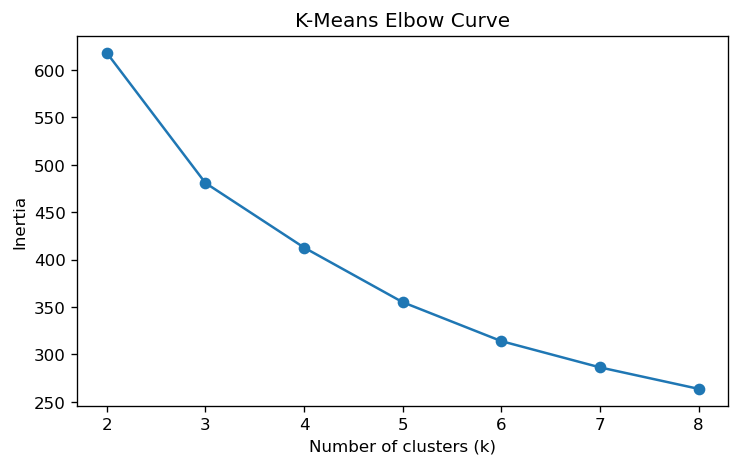

In [36]:
plt.figure(figsize=(7, 4))

plt.plot(
    kmeans_df["k"],
    kmeans_df["inertia"],
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")

plt.show()

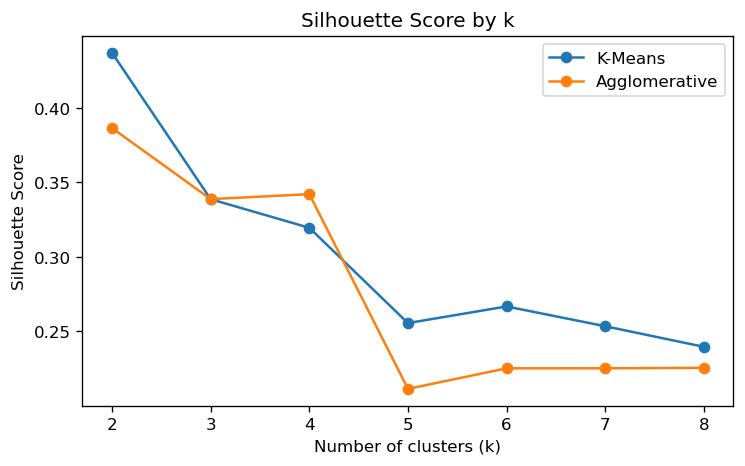

In [37]:
plt.figure(figsize=(7, 4))

plt.plot(
    kmeans_df["k"],
    kmeans_df["silhouette"],
    marker="o",
    label="K-Means"
)

plt.plot(
    agg_df["k"],
    agg_df["silhouette"],
    marker="o",
    label="Agglomerative"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")
plt.legend()
plt.show()

In [38]:
final_model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

df_fe["segment"] = final_model.fit_predict(
    X_scaled
)

df_fe["segment"].value_counts().sort_index()

segment
0    78
1    13
2    34
3    24
Name: count, dtype: int64

In [39]:
profile_metrics = [
    "logins_last_month",
    "avg_session_minutes",
    "feature_clicks",
    "reports_generated",
    "engagement_score",
    "clicks_per_login",
    "exports_per_login",
    "exports_per_100_clicks"
]

segment_mean = (
    df_fe
    .groupby("segment")[profile_metrics]
    .mean()
    .round(2)
)

segment_median = (
    df_fe
    .groupby("segment")[profile_metrics]
    .median()
    .round(2)
)

display(segment_mean)
display(segment_median)

,logins_last_month,avg_session_minutes,feature_clicks,reports_generated,engagement_score,clicks_per_login,exports_per_login,exports_per_100_clicks
segment,,,,,,,,
0,16.08,47.13,71.82,30.88,757.78,4.57,1.95,44.12
1,6.85,29.82,13.00,7.08,226.60,1.86,1.03,55.27
2,6.94,35.61,38.85,14.94,260.37,5.84,2.19,37.82
3,4.33,23.39,14.58,3.33,111.77,3.24,0.72,22.74


,logins_last_month,avg_session_minutes,feature_clicks,reports_generated,engagement_score,clicks_per_login,exports_per_login,exports_per_100_clicks
segment,,,,,,,,
0,16.0,47.55,72.0,31.0,712.55,4.50,1.88,43.15
1,7.0,29.50,14.0,9.0,270.90,1.80,1.00,56.25
2,8.0,37.60,43.0,15.5,282.80,5.89,1.95,37.98
3,3.5,21.80,13.0,3.0,68.85,3.29,0.75,22.25


In [40]:
role_distribution = pd.crosstab(
    df_fe["segment"],
    df_fe["role"],
    normalize="index"
).round(2)

display(role_distribution)

role,Financial Advisor,Institutional Investor,Portfolio Manager,Quantitative Researcher,Retail Trader,Treasury Analyst
segment,,,,,,
0,0.00,0.00,0.06,0.38,0.55,0.00
1,0.54,0.31,0.00,0.00,0.00,0.15
2,0.26,0.03,0.50,0.00,0.06,0.15
3,0.25,0.42,0.00,0.00,0.00,0.33


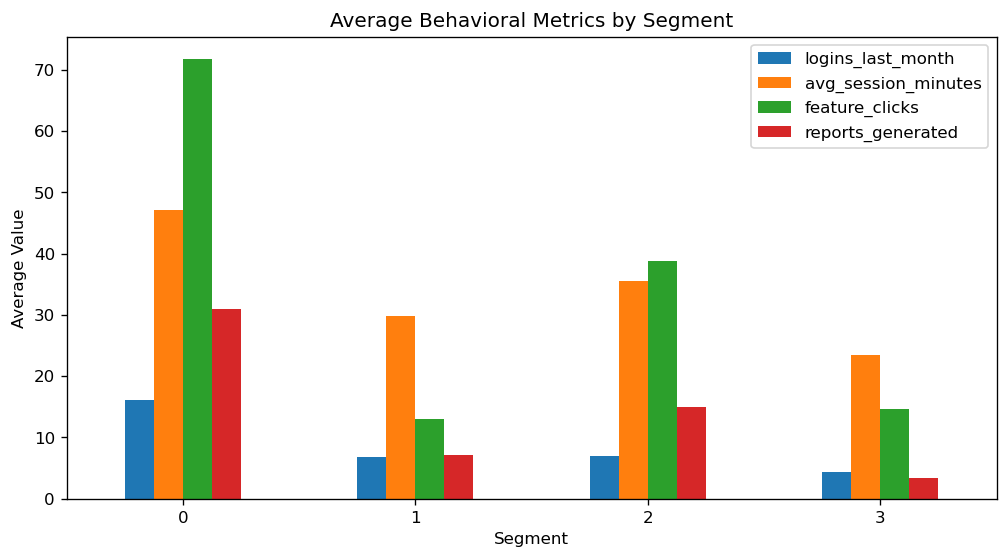

In [41]:
# Segment Mean Bar Chart
plot_metrics = [
    "logins_last_month",
    "avg_session_minutes",
    "feature_clicks",
    "reports_generated"
]

ax = segment_mean[plot_metrics].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_xlabel("Segment")
ax.set_ylabel("Average Value")
ax.set_title(
    "Average Behavioral Metrics by Segment"
)

plt.xticks(rotation=0)
plt.show()

In [42]:
from sklearn.cluster import DBSCAN

dbscan_model = DBSCAN(
    eps=1.2,
    min_samples=6
)

dbscan_labels = dbscan_model.fit_predict(
    X_scaled
)

pd.Series(dbscan_labels).value_counts().sort_index()

-1    30
 0    92
 1    22
 2     5
Name: count, dtype: int64